In [1]:
%reset -f
import sys
sys.path.append("/Users/lingyi/Documents/spatial/colocalization/functions")
import importlib
import tools
importlib.reload(tools)
import os


import spatialdata_io
import scanpy as sc
import numpy as np
import pandas as pd
from scipy import stats


from spatialdata_io._constants._constants import VisiumHDKeys
from spatialdata.models import Image2DModel, ShapesModel, TableModel
from spatialdata.transformations import Affine, Identity, Scale, set_transformation
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from scipy import sparse

/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_red

In [2]:
sys.path.append("/Users/lingyi/Documents/spatial/colocalization/functions")
import tools
importlib.reload(tools)
proc = tools.spatialTool()
outs_path = "/Users/lingyi/Documents/spatial/datasets/HD/visium-hd-cytassist-gene-expression-libraries-human-breast-cancer-ff-ultima-4"


# outs_path = "/Users/lingyi/Documents/spatial/datasets/HD/visium-hd-cytassist-gene-expression-libraries-human-prostate-cancer-ffpe"
adata = proc.visiumHDreader(outs_path, "segmented_outputs")

/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Filtered cells without cluster assignments: 0 removed, 38993 retained (out of 38993 total)


In [3]:
# Define gene signatures
aCAF = ['COL11A1']# consider the late stage only 
# immune_cells = ['MS4A1', 'CCL19', 'TCF7', 'SELL', 'GZMK']# non-exhaustive 
immune_cells = ['GZMA', 'CD8A',  'GZMK', 'CCL19', 'MS4A1']
tumor_epithelial = ['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'ESR1', 'ERBB2']

adata.obs['aCAF_score'] = np.array(adata[:, aCAF].X.mean(axis=1)).flatten()
adata.obs['immune_score'] = np.array(adata[:, immune_cells].X.mean(axis=1)).flatten()
adata.obs['tumor_score'] = np.array(adata[:, tumor_epithelial].X.mean(axis=1)).flatten()


In [20]:
# Patch-based co-localization analysis 
from scipy.stats import pearsonr, spearmanr
import seaborn as sns

def create_patches(adata, n_patches_x=5, n_patches_y=5):
    """
    Divide the spatial coordinates into patches
    """
    coords = adata.obsm['spatial_um']
    x_coords, y_coords = coords[:, 0], coords[:, 1]
    
    # Get coordinate ranges
    x_min, x_max = x_coords.min(), x_coords.max()
    y_min, y_max = y_coords.min(), y_coords.max()
    
    # Create patch boundaries
    x_edges = np.linspace(x_min, x_max, n_patches_x + 1)
    y_edges = np.linspace(y_min, y_max, n_patches_y + 1)
    
    # Assign cells to patches
    patch_ids = np.zeros(len(adata), dtype=int)
    patch_info = []
    
    patch_id = 0
    for j in range(n_patches_y):
        for i in range(n_patches_x):
            # Define patch boundaries
            x_left, x_right = x_edges[i], x_edges[i + 1]
            y_bottom, y_top = y_edges[j], y_edges[j + 1]
            
            # Find cells in this patch
            in_patch = ((x_coords >= x_left) & (x_coords < x_right) & 
                       (y_coords >= y_bottom) & (y_coords < y_top))
            
            # Handle edge case for last patch
            if i == n_patches_x - 1:
                in_patch = in_patch | ((x_coords == x_right) & 
                                     (y_coords >= y_bottom) & (y_coords < y_top))
            if j == n_patches_y - 1:
                in_patch = in_patch | ((x_coords >= x_left) & (x_coords < x_right) & 
                                     (y_coords == y_top))
            if i == n_patches_x - 1 and j == n_patches_y - 1:
                in_patch = in_patch | ((x_coords == x_right) & (y_coords == y_top))
            
            patch_ids[in_patch] = patch_id
            
            patch_info.append({
                'patch_id': patch_id,
                'x_range': (x_left, x_right),
                'y_range': (y_bottom, y_top),
                'n_cells': np.sum(in_patch)
            })
            
            patch_id += 1
    
    return patch_ids, patch_info

# Create patches
print("Creating spatial patches...")
n_patches_x, n_patches_y = 3, 3  # Adjust as needed
patch_ids, patch_info = create_patches(adata, n_patches_x, n_patches_y)
adata.obs['patch_id'] = patch_ids

# Print patch statistics
total_patches = len(patch_info)
cells_per_patch = [info['n_cells'] for info in patch_info]
print(f"Created {total_patches} patches")
print(f"Cells per patch: mean={np.mean(cells_per_patch):.1f}, median={np.median(cells_per_patch):.1f}, std={np.std(cells_per_patch):.1f}")
print(f"Range: {np.min(cells_per_patch)} to {np.max(cells_per_patch)} cells")

Creating spatial patches...
Created 9 patches
Cells per patch: mean=4332.6, median=5173.0, std=1819.5
Range: 775 to 6569 cells


In [21]:
# Statistical analysis of co-localization in patches
from itertools import combinations
from scipy.stats import pearsonr, spearmanr

# Calculate the mean score for each signature in each patch, and compute correlations across all patches. 
def analyze_patch_colocalization(adata, signature_keys=None, min_cells_per_patch=10):

    if signature_keys is None:
        signature_keys = [c for c in adata.obs.columns if c.endswith("_score")]
    
    results = []

    # For loop through all patches
    for patch_id in range(adata.obs['patch_id'].max() + 1):
        patch_mask = adata.obs['patch_id'] == patch_id
        n_cells = np.sum(patch_mask)
        
        if n_cells < min_cells_per_patch:
            continue
        
        patch_data = adata.obs[patch_mask]

        # Skip if any signature has no variation
        if any(np.std(patch_data[key].values) == 0 for key in signature_keys):
            continue
        
        # Start one row for this patch
        row = {
            "patch_id": patch_id,
            "n_cells": n_cells,
        }
        
        # Add mean values for each signature
        for key in signature_keys:
            row[f"{key}_mean"] = np.mean(patch_data[key].values) # LC: is mean appropriate here? need to think more about it

        # Compute pairwise correlations
        for key1, key2 in combinations(signature_keys, 2):
            vals1 = patch_data[key1].values
            vals2 = patch_data[key2].values

            pear_r, pear_p = pearsonr(vals1, vals2)
            spear_r, spear_p = spearmanr(vals1, vals2)

            # Save correlation, pearson and spearman?
            row[f"{key1}__{key2}__pearson_r"] = pear_r
            row[f"{key1}__{key2}__pearson_p"] = pear_p
            row[f"{key1}__{key2}__spearman_r"] = spear_r
            row[f"{key1}__{key2}__spearman_p"] = spear_p

        results.append(row)
    
    return pd.DataFrame(results)


# Save as patch_results, including the mean scores and correlations
print("Analyzing co-localization in patches...")
signature_keys=["aCAF_score", "immune_score", "tumor_score"]
patch_results = analyze_patch_colocalization(adata, signature_keys=signature_keys, min_cells_per_patch=50) # need to change the min_cells_per_patch!!

print(f"Analyzed {len(patch_results)} patches with sufficient cells")
print(f"Total patches created: {adata.obs['patch_id'].nunique()}")

# Display summary statistics
print("\n=== Summary ===")
print(f"Patches analyzed: {len(patch_results)}")
print(f"Mean cells per analyzed patch: {patch_results['n_cells'].mean():.1f}")

Analyzing co-localization in patches...
Analyzed 9 patches with sufficient cells
Total patches created: 9

=== Summary ===
Patches analyzed: 9
Mean cells per analyzed patch: 4332.6


In [22]:
import numpy as np
import pandas as pd
from itertools import combinations

def analyze_patch_overlap(
    patch_results: pd.DataFrame,
    signature_keys,
    arbitrary_threshold=None,
    quantile_threshold=0.75,
):
    """
    Enriches overlap analysis and returns a visualization-ready payload.

    Returns dict with:
      - 'signature_keys': list[str]
      - 'thresholds': dict[sig -> float]
      - 'high_groups': dict[sig -> set(patch_id)]
      - 'pairwise_overlap': dict[(sig1,sig2) -> set(patch_id)]
      - 'all_high_overlap': set(patch_id)
      - 'patch_signatures': DataFrame with ['patch_id','n_cells', f'{sig}_mean'...]
    """

    # Normalize input
    signature_keys = list(signature_keys)
    mean_cols = [f"{sig}_mean" for sig in signature_keys]
    needed_cols = ["patch_id", "n_cells"] + mean_cols
    missing = [c for c in needed_cols if c not in patch_results.columns]
    if missing:
        raise ValueError(f"patch_results is missing columns needed for visualization: {missing}")

    df = patch_results[needed_cols].copy()

    # Compute thresholds
    if arbitrary_threshold is None:
        thresholds = {sig: df[f"{sig}_mean"].quantile(quantile_threshold) for sig in signature_keys}
        print(f"Using {int(quantile_threshold*100)}th percentile thresholds per signature")
    else:
        if isinstance(arbitrary_threshold, list):
            if len(arbitrary_threshold) != len(signature_keys):
                raise ValueError("Length of arbitrary_threshold list must match signature_keys")
            thresholds = dict(zip(signature_keys, arbitrary_threshold))
        elif isinstance(arbitrary_threshold, dict):
            thresholds = {sig: arbitrary_threshold[sig] for sig in signature_keys}
        else:
            thresholds = {sig: float(arbitrary_threshold) for sig in signature_keys}
        print(f"Using arbitrary thresholds: {thresholds}")

    for sig in signature_keys:
        print(f"  {sig}: {thresholds[sig]:.4f}")

    # High groups. This can be used to define th threshold for each signature
    high_groups = {}
    for sig in signature_keys:
        highs = df.loc[df[f"{sig}_mean"] >= thresholds[sig], "patch_id"].astype(int).tolist()
        high_groups[sig] = set(highs)
        print(f"{sig}: {len(highs)} high patches")

    # Pairwise overlaps
    pairwise_overlap = {}
    print("\n=== Pairwise overlaps ===")
    for sig1, sig2 in combinations(signature_keys, 2):
        overlap = high_groups[sig1] & high_groups[sig2]
        pairwise_overlap[(sig1, sig2)] = overlap
        print(f"{sig1} ∩ {sig2}: {len(overlap)} patches")

    # All-signature overlap 
    if len(signature_keys) >= 2:
        all_high_overlap = set.intersection(*high_groups.values()) if high_groups else set()
    else:
        all_high_overlap = high_groups[signature_keys[0]]

    print(f"\nPatches high in ALL {len(signature_keys)} signatures: {len(all_high_overlap)}")

    return {
        "signature_keys": signature_keys,
        "thresholds": thresholds,
        "high_groups": high_groups,
        "pairwise_overlap": pairwise_overlap,
        "all_high_overlap": all_high_overlap,
        "patch_signatures": df.sort_values("patch_id").reset_index(drop=True),
    }

signature_keys = ["aCAF_score", "immune_score", "tumor_score"]
overlap_results = analyze_patch_overlap(
    patch_results, signature_keys,
    arbitrary_threshold=[0.5, 0.5, 0.5]  
)


Using arbitrary thresholds: {'aCAF_score': 0.5, 'immune_score': 0.5, 'tumor_score': 0.5}
  aCAF_score: 0.5000
  immune_score: 0.5000
  tumor_score: 0.5000
aCAF_score: 1 high patches
immune_score: 3 high patches
tumor_score: 4 high patches

=== Pairwise overlaps ===
aCAF_score ∩ immune_score: 0 patches
aCAF_score ∩ tumor_score: 1 patches
immune_score ∩ tumor_score: 0 patches

Patches high in ALL 3 signatures: 0


In [23]:
from __future__ import annotations

from typing import Any, Dict, Iterable, List, Set, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import pearsonr

# Remove the _score suffix
def _pretty_sig(sig: str) -> str:
    """Turn 'aCAF_score' -> 'aCAF', 'tumor_score' -> 'tumor'."""
    return sig.replace("_score", "")

# Helper function to create scatter plots
def _pair_masks(
    patch_ids: np.ndarray,
    high_groups: Dict[str, Set[int]],
    sig_x: str,
    sig_y: str,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Boolean masks for other, x-only, y-only, both."""
    hx = np.isin(patch_ids, list(high_groups[sig_x]))
    hy = np.isin(patch_ids, list(high_groups[sig_y]))
    both = hx & hy
    x_only = hx & ~hy
    y_only = hy & ~hx
    other = ~(hx | hy)
    return other, x_only, y_only, both


def _scatter_means(
    ax: plt.Axes,
    df: pd.DataFrame,
    sig_x: str,
    sig_y: str,
    high_groups: Dict[str, Set[int]],
    thresholds: Dict[str, float],
    colors: Dict[Any, str],
) -> None:
    """Scatter of patch means with highlights + Pearson r annotation."""
    x = df[f"{sig_x}_mean"].to_numpy()
    y = df[f"{sig_y}_mean"].to_numpy()
    pid = df["patch_id"].to_numpy()

    other, x_only, y_only, both = _pair_masks(pid, high_groups, sig_x, sig_y)

    # Base layer: other patches
    ax.scatter(x[other], y[other], s=30, alpha=0.5, label="Other patches", c="lightgray")

    # Highlights
    if x_only.any():
        ax.scatter(x[x_only], y[x_only], s=50, alpha=0.9,
                   label=f"{_pretty_sig(sig_x)}-high", c=colors.get(sig_x, "red"))
    if y_only.any():
        ax.scatter(x[y_only], y[y_only], s=50, alpha=0.9,
                   label=f"{_pretty_sig(sig_y)}-high", c=colors.get(sig_y, "blue"))
    if both.any():
        ax.scatter(x[both], y[both], s=90, alpha=1.0, marker="*", edgecolor="black",
                   label="Both high", c=colors.get((sig_x, sig_y), "black"))

    # Threshold reference lines
    ax.axvline(thresholds[sig_x], linestyle="--", alpha=0.6, linewidth=1)
    ax.axhline(thresholds[sig_y], linestyle="--", alpha=0.6, linewidth=1)

    # Pearson r across patches
    if np.std(x) > 0 and np.std(y) > 0:
        r, p = pearsonr(x, y)
        ax.text(0.02, 0.98, f"r={r:.2f}\np={p:.1e}", transform=ax.transAxes,
                va="top", ha="left", bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

    ax.set_xlabel(f"{_pretty_sig(sig_x)} mean per patch")
    ax.set_ylabel(f"{_pretty_sig(sig_y)} mean per patch")
    ax.grid(True, alpha=0.25)


def _categorical_spatial(
    ax: plt.Axes,
    adata: Any,
    overlap_results: Dict[str, Any],
    focus_pair: Tuple[str, str] | None = None,
) -> None:
    """Categorical spatial map for a focused signature pair."""
    sigs: List[str] = overlap_results["signature_keys"]
    df: pd.DataFrame = overlap_results["patch_signatures"]
    pid = df["patch_id"].to_numpy()

    sigA, sigB = (focus_pair if focus_pair else (sigs[0], sigs[1] if len(sigs) > 1 else sigs[0]))

    A: Set[int] = overlap_results["high_groups"][sigA]
    B: Set[int] = overlap_results["high_groups"][sigB]
    AB = A & B

    # Per-patch label map: 0 other, 1 A-only, 2 B-only, 3 both
    patch_label = {int(p): 0 for p in pid}
    for p in A - AB:
        patch_label[int(p)] = 1
    for p in B - AB:
        patch_label[int(p)] = 2
    for p in AB:
        patch_label[int(p)] = 3

    # Map labels to cells
    cell_patch = adata.obs["patch_id"].astype(int).to_numpy()
    labels = np.vectorize(lambda p: patch_label.get(int(p), 0))(cell_patch)

    # Colors 
    color_map = {0: "lightgray", 1: "red", 2: "blue", 3: "black"}
    coords = adata.obsm["spatial_um"]
    ax.scatter(coords[:, 0], coords[:, 1], s=1, c=[color_map[int(l)] for l in labels], alpha=0.8)

    ax.set_aspect("equal")
    ax.invert_yaxis()  # Invert Y-axis to match sc.pl.spatial
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(f"Spatial overlap: {_pretty_sig(sigA)} vs {_pretty_sig(sigB)}")

    legend_elems = [
        Patch(facecolor="lightgray", label="Other"),
        Patch(facecolor="red", label=f"{_pretty_sig(sigA)}-high only"),
        Patch(facecolor="blue", label=f"{_pretty_sig(sigB)}-high only"),
        Patch(facecolor="black", label="Both high"),
    ]
    ax.legend(handles=legend_elems, loc="upper right", frameon=True)


def _spatial_heatmap_panel(
    fig: plt.Figure,
    axes: Iterable[plt.Axes],
    adata: Any,
    overlap_results: Dict[str, Any],
    cmap: str = "viridis",
) -> None:
    """1xN panel: up to first three signatures, color cells by their PATCH mean."""
    sigs = overlap_results["signature_keys"][:3]
    df = overlap_results["patch_signatures"]
    lookups = {sig: dict(zip(df["patch_id"].astype(int), df[f"{sig}_mean"].to_numpy())) for sig in sigs}

    cell_patch = adata.obs["patch_id"].astype(int).to_numpy()
    coords = adata.obsm["spatial_um"]

    for ax, sig in zip(axes, sigs):
        vals = np.vectorize(lambda p: lookups[sig].get(int(p), np.nan))(cell_patch)
        sc = ax.scatter(coords[:, 0], coords[:, 1], s=1, c=vals, alpha=0.85, cmap=cmap)
        ax.set_aspect("equal")
        ax.invert_yaxis()  # Invert Y-axis to match sc.pl.spatial
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_title(f"Spatial intensity: {_pretty_sig(sig)} (patch mean)")
        cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
        cbar.set_label("Patch mean")


def _choose_main_sigs(signature_keys: List[str]) -> List[str]:
    """Take up to first 3 signatures; if fewer, pad by repeating the first."""
    if not signature_keys:
        raise ValueError("signature_keys must contain at least 1 signature.")
    if len(signature_keys) >= 3:
        return signature_keys[:3]
    if len(signature_keys) == 2:
        return [signature_keys[0], signature_keys[1], signature_keys[0]]
    return [signature_keys[0]] * 3



def plot_scatter_overlaps(
    df: pd.DataFrame,
    thresholds: Dict[str, float],
    high_groups: Dict[str, Set[int]],
    signature_keys: List[str],
) -> List[plt.Figure]:
    """
    Returns two independent scatter figures:
      1) sig0 vs sig2
      2) sig0 vs sig1
    """
    main = _choose_main_sigs(signature_keys)
    colors = {
        main[0]: "red",
        main[1]: "blue",
        main[2]: "green",
        (main[0], main[2]): "black",
        (main[0], main[1]): "black",
    }

    # fig 1: sig0 vs sig2
    fig1, ax1 = plt.subplots(figsize=(6, 5))
    _scatter_means(ax1, df, main[0], main[2], high_groups, thresholds, colors)
    ax1.set_title(f"{_pretty_sig(main[0])} vs {_pretty_sig(main[2])} (patch means)")
    ax1.legend()

    # fig 2: sig0 vs sig1
    fig2, ax2 = plt.subplots(figsize=(6, 5))
    _scatter_means(ax2, df, main[0], main[1], high_groups, thresholds, colors)
    ax2.set_title(f"{_pretty_sig(main[0])} vs {_pretty_sig(main[1])} (patch means)")
    ax2.legend()

    return [fig1, fig2]

def plot_scatter_overlap(
    df: pd.DataFrame,
    thresholds: Dict[str, float],
    high_groups: Dict[str, Set[int]],
    sig_x: str,
    sig_y: str,
) -> plt.Figure:
    """
    Returns a scatter figure for the given signature pair (sig_x vs sig_y).
    """
    colors = {
        sig_x: "red",
        sig_y: "blue",
        (sig_x, sig_y): "black",
    }

    fig, ax = plt.subplots(figsize=(6, 5))
    _scatter_means(ax, df, sig_x, sig_y, high_groups, thresholds, colors)
    ax.set_title(f"{_pretty_sig(sig_x)} vs {_pretty_sig(sig_y)} (patch means)")
    ax.legend()
    return fig
    
def plot_overlap_bars(
    high_groups: Dict[str, Set[int]],
    all_high_overlap: Set[int],
    signature_keys: List[str],
) -> plt.Figure:

    main = _choose_main_sigs(signature_keys)

    cats: List[str] = []
    vals: List[int] = []
    for sx, sy in [(main[0], main[2]), (main[0], main[1])]:
        A, B = high_groups[sx], high_groups[sy]
        AB = A & B
        cats.extend([f"{_pretty_sig(sx)}-only", f"{_pretty_sig(sy)}-only", "Both high"])
        vals.extend([len(A - AB), len(B - AB), len(AB)])

    if len(signature_keys) >= 3:
        cats.append("All high")
        vals.append(len(all_high_overlap))

    fig, ax = plt.subplots(figsize=(7, 5))
    x = np.arange(len(cats))
    bars = ax.bar(x, vals, color=plt.cm.tab10.colors[: len(vals)], alpha=0.8)
    ax.set_xticks(x, cats, rotation=35, ha="right")
    ax.set_ylabel("Number of patches")
    ax.set_title("Patch Group Sizes")
    ax.grid(True, axis="y", alpha=0.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5, str(v),
                ha="center", va="bottom", fontsize=9)
    return fig


def plot_categorical_spatial_overlap(
    adata: Any,
    overlap_results: Dict[str, Any],
    pair: Tuple[str, str] | None = None,
) -> plt.Figure:
    """One categorical spatial overlap figure; defaults to (sig0, sig2) if pair not provided."""
    sigs: List[str] = overlap_results["signature_keys"]
    main = _choose_main_sigs(sigs)
    focus_pair = pair if pair else (main[0], main[2])

    fig, ax = plt.subplots(figsize=(6, 5))
    _categorical_spatial(ax, adata, overlap_results, focus_pair=focus_pair)
    fig.suptitle("Categorical spatial overlap", y=0.98)
    return fig


def plot_patch_heatmap(df: pd.DataFrame, signature_keys: List[str]) -> plt.Figure:
    """Heatmap of patch means (no clustering)."""
    main = _choose_main_sigs(signature_keys)
    heat = df[[f"{s}_mean" for s in main]].T.to_numpy()

    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(heat, aspect="auto")
    ax.set_yticks(np.arange(len(main)))
    ax.set_yticklabels([_pretty_sig(s) for s in main])
    ax.set_xlabel("Patch index (sorted by patch_id)")
    ax.set_title("Patch means (no clustering)")
    plt.colorbar(im, ax=ax, label="Mean score")
    return fig


def plot_spatial_heatmaps(adata: Any, overlap_results: Dict[str, Any]) -> plt.Figure:
    """1×N (N≤3) continuous spatial heatmaps of patch means."""
    sigs = overlap_results["signature_keys"][:3]
    n = max(1, min(3, len(sigs)))
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    axes = np.array([axes]) if not isinstance(axes, np.ndarray) else axes
    _spatial_heatmap_panel(fig, axes, adata, overlap_results, cmap="viridis")
    fig.suptitle("Spatial continuous heatmaps (patch means)", y=1.02)
    fig.tight_layout()
    return fig

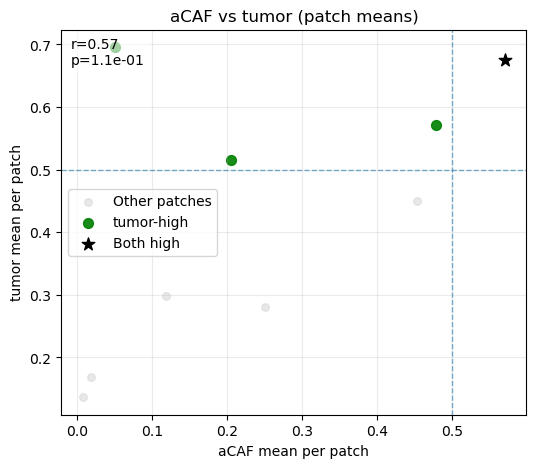

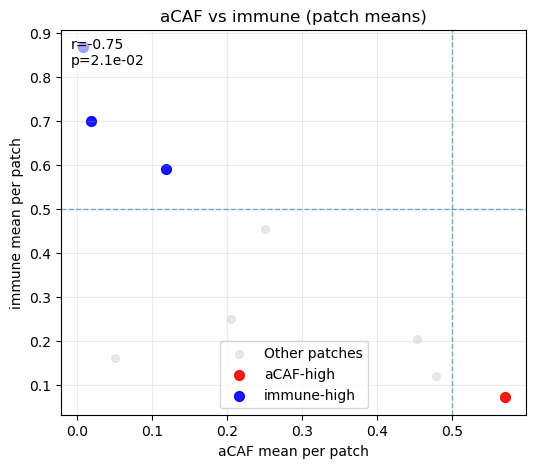

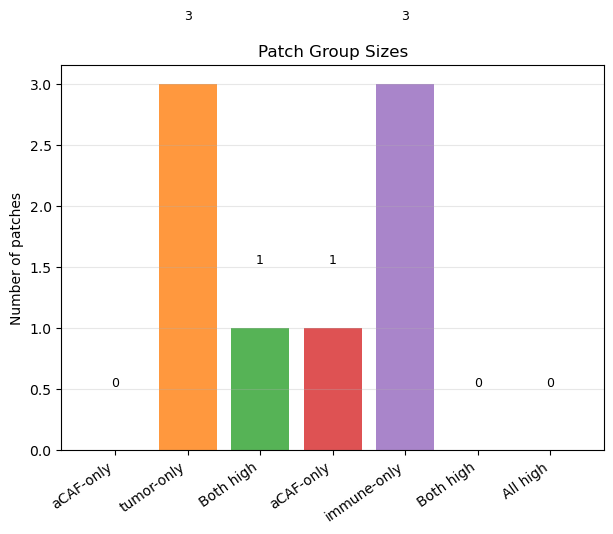

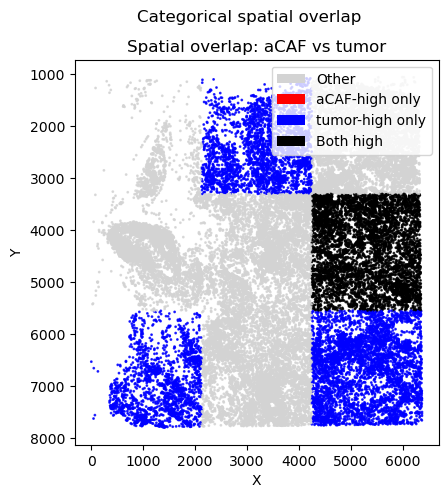

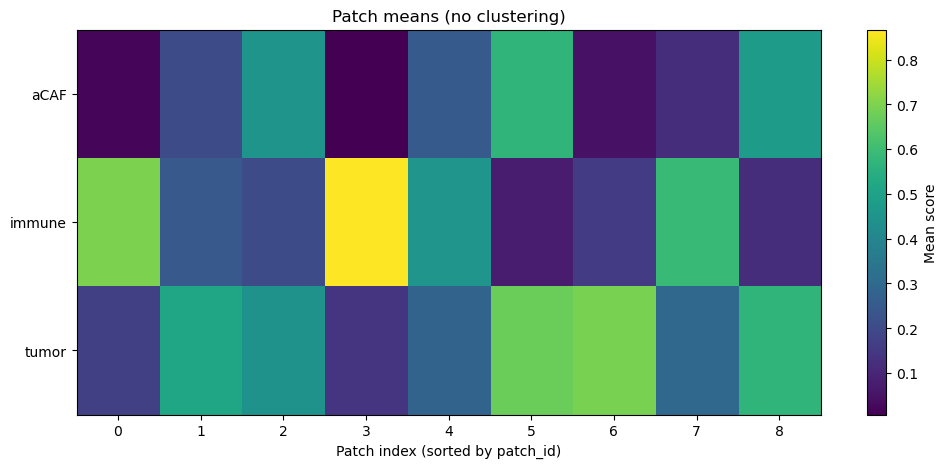

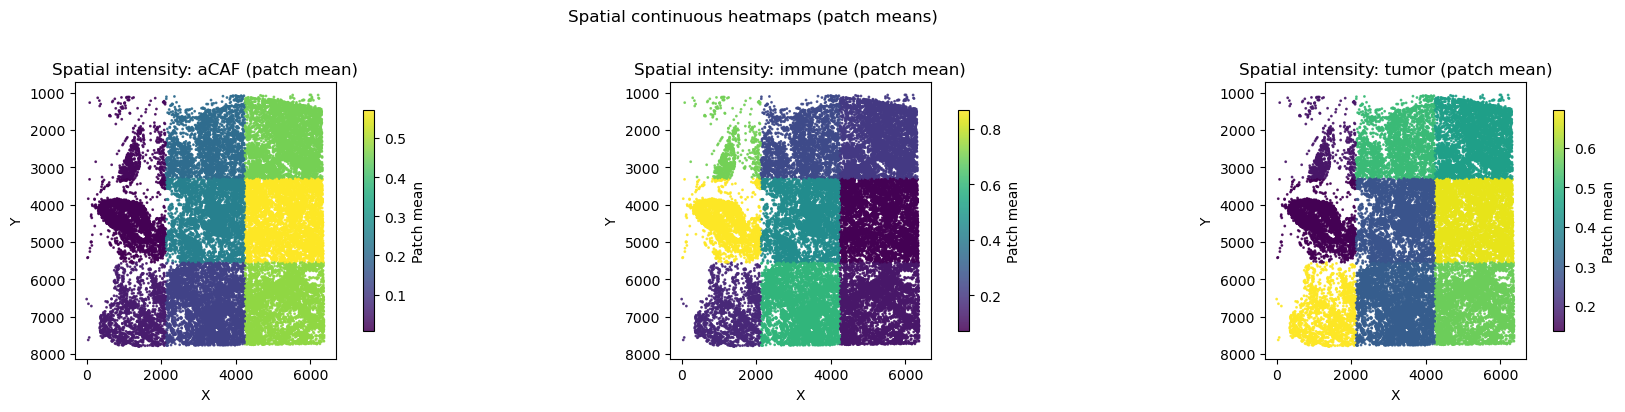

In [24]:
sigs = overlap_results["signature_keys"]
df = overlap_results["patch_signatures"]
thresholds = overlap_results["thresholds"]
high_groups = overlap_results["high_groups"]
all_high = overlap_results.get("all_high_overlap", set())

figs_scatter = plot_scatter_overlaps(df, thresholds, high_groups, sigs)
# fig_1 = plot_scatter_overlap(df, thresholds, high_groups, 'aCAF_score', 'immune_score')
# fig_2 = plot_scatter_overlap(df, thresholds, high_groups, 'aCAF_score', 'tumor_score')
# fig_3 = plot_scatter_overlap(df, thresholds, high_groups, 'immune_score', 'tumor_score')
fig_bars = plot_overlap_bars(high_groups, all_high, sigs)
fig_cat = plot_categorical_spatial_overlap(adata, overlap_results)
fig_heat = plot_patch_heatmap(df, sigs)
fig_spatial = plot_spatial_heatmaps(adata, overlap_results)

## Select and visualize patches with high tumor and stromal (aCAF) scores

In [25]:
# Select patches with high tumor AND high stromal (aCAF) scores
high_groups = overlap_results["high_groups"]
thresholds = overlap_results["thresholds"]

# Get patches that are high in both aCAF and tumor
high_aCAF_tumor = high_groups['aCAF_score'] & high_groups['tumor_score']

print(f"Total patches with high aCAF AND tumor: {len(high_aCAF_tumor)}")
print(f"Patch IDs: {sorted(high_aCAF_tumor)}")

# Get the patch information
df = overlap_results["patch_signatures"]
high_patches_df = df[df['patch_id'].isin(high_aCAF_tumor)].copy()

print("\n=== Statistics for high aCAF + tumor patches ===")
print(high_patches_df[['patch_id', 'n_cells', 'aCAF_score_mean', 'tumor_score_mean', 'immune_score_mean']].to_string())

print(f"\nMean aCAF score: {high_patches_df['aCAF_score_mean'].mean():.4f}")
print(f"Mean tumor score: {high_patches_df['tumor_score_mean'].mean():.4f}")
print(f"Mean immune score: {high_patches_df['immune_score_mean'].mean():.4f}")

Total patches with high aCAF AND tumor: 1
Patch IDs: [5]

=== Statistics for high aCAF + tumor patches ===
   patch_id  n_cells  aCAF_score_mean  tumor_score_mean  immune_score_mean
5         5     5756         0.570975          0.674609           0.071815

Mean aCAF score: 0.5710
Mean tumor score: 0.6746
Mean immune score: 0.0718


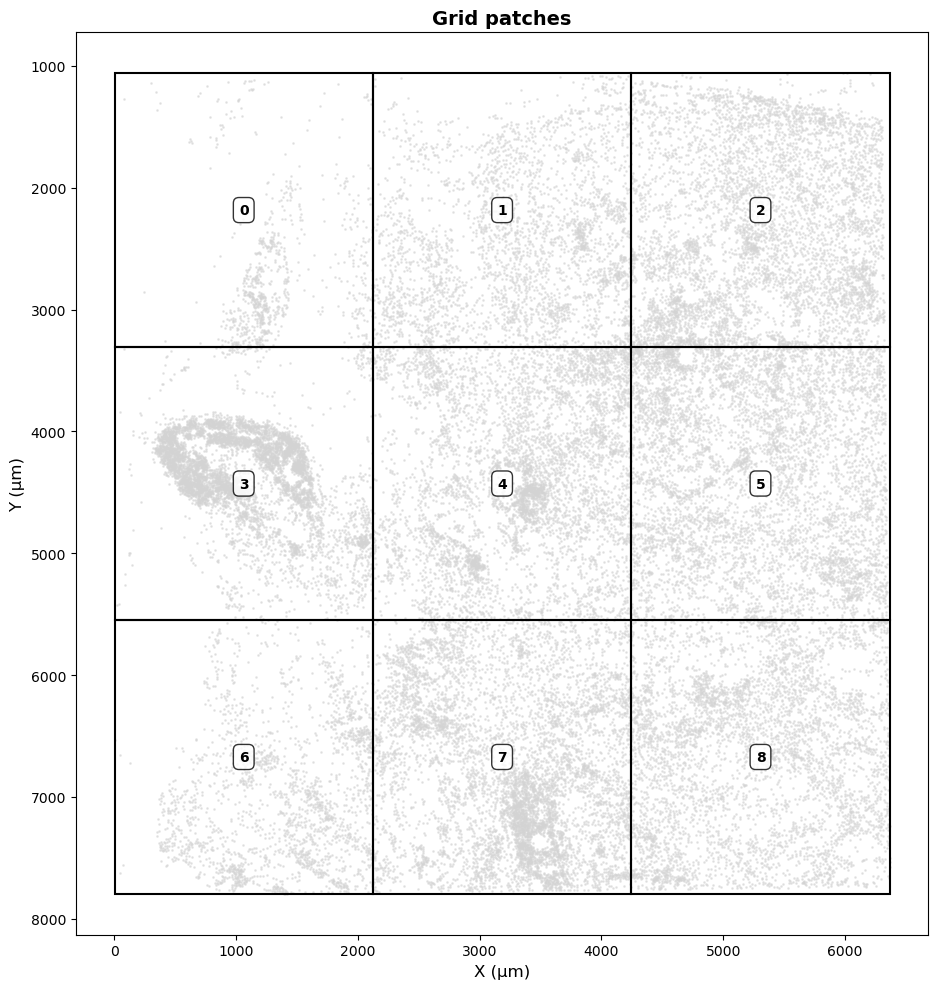

Grid size: 3 × 3 = 9 equal-sized patches


In [26]:
# Show all patch IDs with equal-sized grid borders on the full tissue section
fig, ax = plt.subplots(figsize=(12, 10))

# Plot all cells in gray
coords = adata.obsm["spatial_um"]
ax.scatter(coords[:, 0], coords[:, 1], s=1, c='lightgray', alpha=0.5)

# Get the actual grid boundaries from patch_info (created during patching)
from matplotlib.patches import Rectangle

# Draw equal-sized grid patches using the stored patch_info
for info in patch_info:
    patch_id = info['patch_id']
    x_left, x_right = info['x_range']
    y_bottom, y_top = info['y_range']
    
    # Draw border with equal coordinate sizes
    rect = Rectangle((x_left, y_bottom), x_right-x_left, y_top-y_bottom, 
                     linewidth=1.5, edgecolor='black', facecolor='none')
    ax.add_patch(rect)
    
    # Add patch ID label at the grid centroid
    centroid_x = (x_left + x_right) / 2
    centroid_y = (y_bottom + y_top) / 2
    ax.text(centroid_x, centroid_y, str(patch_id), 
            fontsize=10, ha='center', va='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='black'))

ax.set_aspect("equal")
ax.invert_yaxis()  # Invert Y-axis to match sc.pl.spatial
ax.set_xlabel("X (μm)", fontsize=12)
ax.set_ylabel("Y (μm)", fontsize=12)
ax.set_title("Grid patches", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Grid size: {n_patches_x} × {n_patches_y} = {len(patch_info)} equal-sized patches")

## Visualize individual patch gene expression

In [32]:
# ===== USER CONFIGURATION =====
selected_patch_id = 1
# ==============================

# Extract patch data
patch_mask = adata.obs['patch_id'] == selected_patch_id
patch_adata = adata[patch_mask].copy()
patch_coords = patch_adata.obsm["spatial_um"]

print(f"✓ Selected patch: {selected_patch_id}")
print(f"✓ Number of cells: {len(patch_adata)}")

# Show patch statistics if available
if selected_patch_id in df['patch_id'].values:
    patch_stats = df[df['patch_id'] == selected_patch_id].iloc[0]
    print(f"\n=== Patch {selected_patch_id} Statistics ===")
    print(f"  aCAF score mean: {patch_stats['aCAF_score_mean']:.4f}")
    print(f"  Tumor score mean: {patch_stats['tumor_score_mean']:.4f}")
    print(f"  Immune score mean: {patch_stats['immune_score_mean']:.4f}")


✓ Selected patch: 1
✓ Number of cells: 3041

=== Patch 1 Statistics ===
  aCAF score mean: 0.2050
  Tumor score mean: 0.5148
  Immune score mean: 0.2490


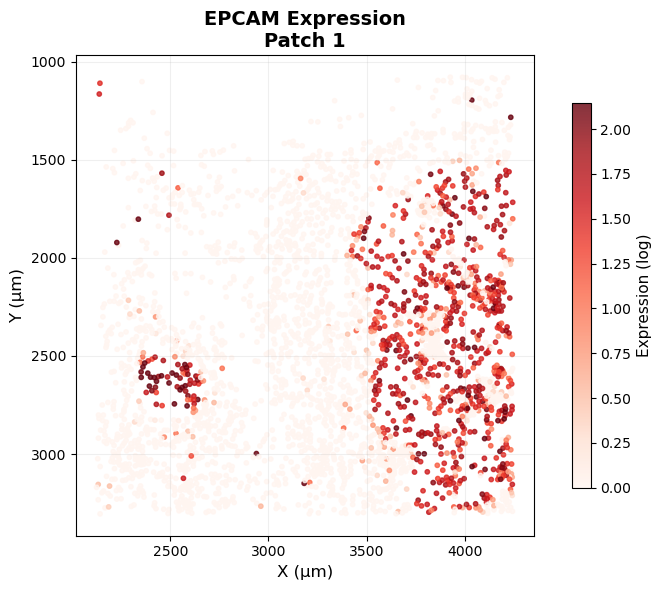


=== EPCAM Expression Statistics ===
  Mean: 0.4199, Median: 0.0000
  Min: 0.0000, Max: 3.8597
  Cells expressing (>0): 905 (29.8%)


In [33]:
# Visualize single gene expression
gene = "EPCAM"  

gene_expr = np.array(patch_adata[:, gene].X.toarray()).flatten()

fig, ax = plt.subplots(figsize=(8, 6))

# Calculate vmax using 95th percentile
vmax = np.percentile(gene_expr[gene_expr > 0], 95) if (gene_expr > 0).any() else gene_expr.max()

# Create scatter plot
sc = ax.scatter(patch_coords[:, 0], patch_coords[:, 1], 
                s=10, c=gene_expr, cmap='Reds', alpha=0.8, vmin=0, vmax=vmax)

ax.set_aspect("equal")
ax.invert_yaxis()  # Invert Y-axis to match sc.pl.spatial
ax.set_xlabel("X (μm)", fontsize=12)
ax.set_ylabel("Y (μm)", fontsize=12)
ax.set_title(f"{gene} Expression\nPatch {selected_patch_id}", fontsize=14, fontweight='bold')

cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('Expression (log)', fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Print expression statistics
print(f"\n=== {gene} Expression Statistics ===")
print(f"  Mean: {gene_expr.mean():.4f}, Median: {np.median(gene_expr):.4f}")
print(f"  Min: {gene_expr.min():.4f}, Max: {gene_expr.max():.4f}")
print(f"  Cells expressing (>0): {(gene_expr > 0).sum()} ({100*(gene_expr > 0).sum()/len(gene_expr):.1f}%)")


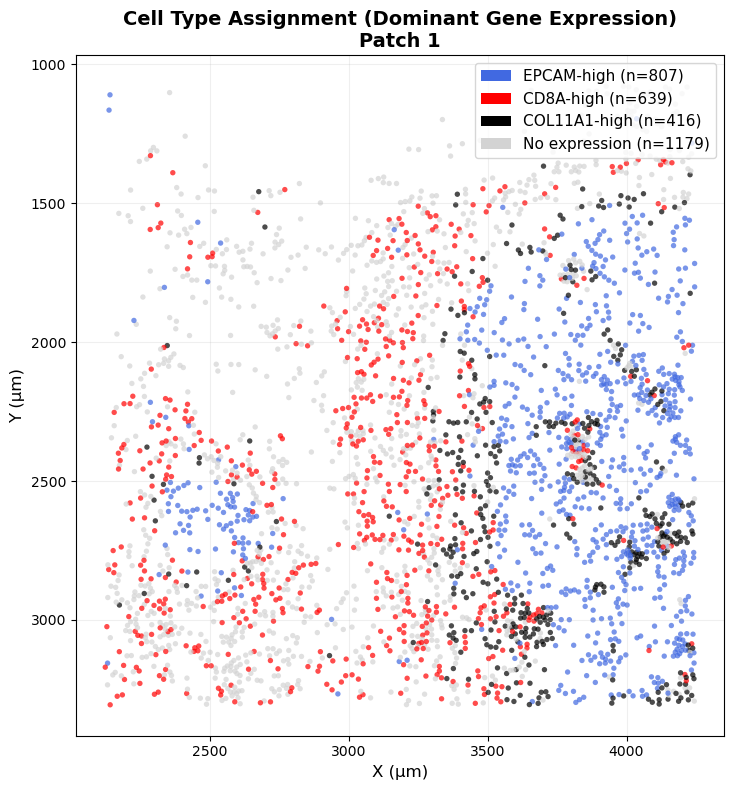


=== Cell Type Assignment Statistics ===
Total cells: 3041
  EPCAM-high: 807 (26.5%)
  CD8A-high: 639 (21.0%)
  COL11A1-high: 416 (13.7%)
  No expression: 1179 (38.8%)


In [35]:
# Visualize three genes with cell type assignment (dominant gene)
# ===== USER CONFIGURATION =====
genes = ['EPCAM', 'CD8A', 'COL11A1']  # Modify this list to change genes
colors = ['royalblue', 'red', 'black']      # Corresponding colors
# ==============================

fig, ax = plt.subplots(figsize=(10, 8))

# Create color map
color_map = {gene: color for gene, color in zip(genes, colors)}

# Extract expression for all genes
gene_expressions = {}
for gene in genes:
    gene_expressions[gene] = np.array(patch_adata[:, gene].X.toarray()).flatten()

# Stack expressions and find dominant gene for each cell
expr_matrix = np.stack([gene_expressions[gene] for gene in genes], axis=1)  # Shape: (n_cells, n_genes)
dominant_gene_idx = np.argmax(expr_matrix, axis=1)  # Index of max expression per cell

# Filter cells: only assign if expression > 0
has_expression = np.max(expr_matrix, axis=1) > 0

# Create color array for each cell
cell_colors = []
cell_labels = []
for i in range(len(patch_coords)):
    if has_expression[i]:
        gene = genes[dominant_gene_idx[i]]
        cell_colors.append(color_map[gene])
        cell_labels.append(gene)
    else:
        cell_colors.append('lightgray')
        cell_labels.append('No expression')

# Plot cells colored by dominant gene
ax.scatter(patch_coords[:, 0], patch_coords[:, 1], 
           s=15, c=cell_colors, alpha=0.7, edgecolors='none')

ax.set_aspect("equal")
ax.invert_yaxis()  # Invert Y-axis to match sc.pl.spatial
ax.set_xlabel("X (μm)", fontsize=12)
ax.set_ylabel("Y (μm)", fontsize=12)
ax.set_title(f"Cell Type Assignment (Dominant Gene Expression)\nPatch {selected_patch_id}", 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)

# Create legend
from matplotlib.patches import Patch
legend_elements = []
for gene, color in zip(genes, colors):
    count = sum([1 for l in cell_labels if l == gene])
    legend_elements.append(Patch(facecolor=color, label=f'{gene}-high (n={count})'))
no_expr = sum([1 for l in cell_labels if l == "No expression"])
legend_elements.append(Patch(facecolor='lightgray', label=f'No expression (n={no_expr})'))

ax.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=11)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n=== Cell Type Assignment Statistics ===")
print(f"Total cells: {len(patch_coords)}")
for gene in genes:
    count = sum([1 for l in cell_labels if l == gene])
    pct = 100 * count / len(patch_coords)
    print(f"  {gene}-high: {count} ({pct:.1f}%)")
print(f"  No expression: {no_expr} ({100*no_expr/len(patch_coords):.1f}%)")


/var/folders/6m/776mbt0s5f9_80ty6x7dq4br0000gn/T/ipykernel_71458/1303551294.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


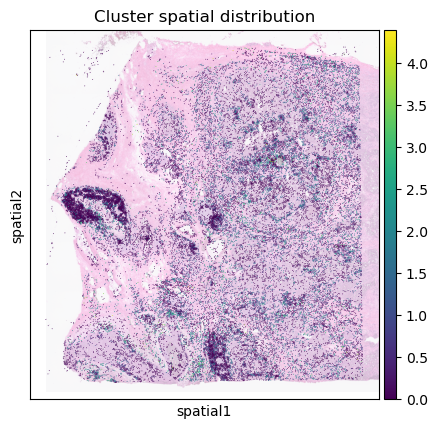

In [30]:
import scanpy as sc
sc.pl.spatial(
    adata,
    color="THBS2",
    img_key="hires",
    spot_size=30,
    title="Cluster spatial distribution",
    alpha_img=0.3
)


In [31]:
import os

# Create output directory if it doesn't exist
geneSelect = 'FOXP3'  # Modify this to change the middle gene
output_dir = "/Users/lingyi/Downloads/patches/" + 'one'
os.makedirs(output_dir, exist_ok=True)

# ===== USER CONFIGURATION =====

genes = ['EPCAM', geneSelect, 'LUM']  # Modify this list to change genes
colors = ['royalblue', 'red', 'black']      # Corresponding colors
# ==============================

# Create color map
color_map = {gene: color for gene, color in zip(genes, colors)}

# Loop through all patch IDs
all_patch_ids = sorted(adata.obs['patch_id'].unique())
print(f"Processing {len(all_patch_ids)} patches...")

for selected_patch_id in all_patch_ids:
    # Extract patch data
    patch_mask = adata.obs['patch_id'] == selected_patch_id
    patch_adata = adata[patch_mask].copy()
    patch_coords = patch_adata.obsm["spatial_um"]
    
    # Skip patches with too few cells
    if len(patch_adata) < 10:
        print(f"  Skipping patch {selected_patch_id} (only {len(patch_adata)} cells)")
        continue
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Extract expression for all genes
    gene_expressions = {}
    for gene in genes:
        gene_expressions[gene] = np.array(patch_adata[:, gene].X.toarray()).flatten()
    
    # Stack expressions and find dominant gene for each cell
    expr_matrix = np.stack([gene_expressions[gene] for gene in genes], axis=1)
    dominant_gene_idx = np.argmax(expr_matrix, axis=1)
    
    # Filter cells: only assign if expression > 0
    has_expression = np.max(expr_matrix, axis=1) > 0
    
    # Create color array for each cell
    cell_colors = []
    cell_labels = []
    for i in range(len(patch_coords)):
        if has_expression[i]:
            gene = genes[dominant_gene_idx[i]]
            cell_colors.append(color_map[gene])
            cell_labels.append(gene)
        else:
            cell_colors.append('lightgray')
            cell_labels.append('No expression')
    
    # Plot cells colored by dominant gene
    ax.scatter(patch_coords[:, 0], patch_coords[:, 1], 
               s=15, c=cell_colors, alpha=0.7, edgecolors='none')
    
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xlabel("X (μm)", fontsize=12)
    ax.set_ylabel("Y (μm)", fontsize=12)
    ax.set_title(f"Cell Type Assignment (Dominant Gene Expression)\nPatch {selected_patch_id}", 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.2)
    
    # Create legend
    from matplotlib.patches import Patch
    legend_elements = []
    for gene, color in zip(genes, colors):
        count = sum([1 for l in cell_labels if l == gene])
        legend_elements.append(Patch(facecolor=color, label=f'{gene}-high (n={count})'))
    no_expr = sum([1 for l in cell_labels if l == "No expression"])
    legend_elements.append(Patch(facecolor='lightgray', label=f'No expression (n={no_expr})'))
    
    ax.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=11)
    
    plt.tight_layout()
    
    # Save figure
    # output_path = os.path.join(output_dir, f"patch_{selected_patch_id:02d}_cell_types.png")
    output_path = os.path.join(output_dir, f"patch_{selected_patch_id:02d}_{geneSelect}_cell_types.png")

    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    
    print(f"  ✓ Saved patch {selected_patch_id} to {output_path}")

print(f"\n✓ All patches saved to {output_dir}")

Processing 9 patches...
  ✓ Saved patch 0 to /Users/lingyi/Downloads/patches/one/patch_00_FOXP3_cell_types.png
  ✓ Saved patch 1 to /Users/lingyi/Downloads/patches/one/patch_01_FOXP3_cell_types.png
  ✓ Saved patch 2 to /Users/lingyi/Downloads/patches/one/patch_02_FOXP3_cell_types.png
  ✓ Saved patch 3 to /Users/lingyi/Downloads/patches/one/patch_03_FOXP3_cell_types.png
  ✓ Saved patch 4 to /Users/lingyi/Downloads/patches/one/patch_04_FOXP3_cell_types.png
  ✓ Saved patch 5 to /Users/lingyi/Downloads/patches/one/patch_05_FOXP3_cell_types.png
  ✓ Saved patch 6 to /Users/lingyi/Downloads/patches/one/patch_06_FOXP3_cell_types.png
  ✓ Saved patch 7 to /Users/lingyi/Downloads/patches/one/patch_07_FOXP3_cell_types.png
  ✓ Saved patch 8 to /Users/lingyi/Downloads/patches/one/patch_08_FOXP3_cell_types.png

✓ All patches saved to /Users/lingyi/Downloads/patches/one
